# Classificação de Dataset com MLP vs CNN
Comparação entre abordagens de Machine Learning (MLP) e Deep Learning (CNN).

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

c:\Users\pichau\.conda\envs\deep-learning\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\pichau\.conda\envs\deep-learning\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## 2. Tratamento dos Dados
Carregamento e pré-processamento do dataset.

Os dados devem ser carregados novamente antes da execução de cada modelo.

In [ ]:
# Exemplo: substitua pelo seu dataset
from sklearn.datasets import load_digits

data = load_digits()
X = data.images
y = data.target

# Pré-processamento dos dados
# Normalização
X = X / 16.0

# Flatten para MLP
X_flat = X.reshape((X.shape[0], -1))

# Split
X_train_f, X_test_f, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42)
X_train_c, X_test_c, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)

### Visualização do Dataset Digits

Formato das imagens originais: (1797, 8, 8)
Dimensão de cada imagem: (8, 8)
Número de classes: 10


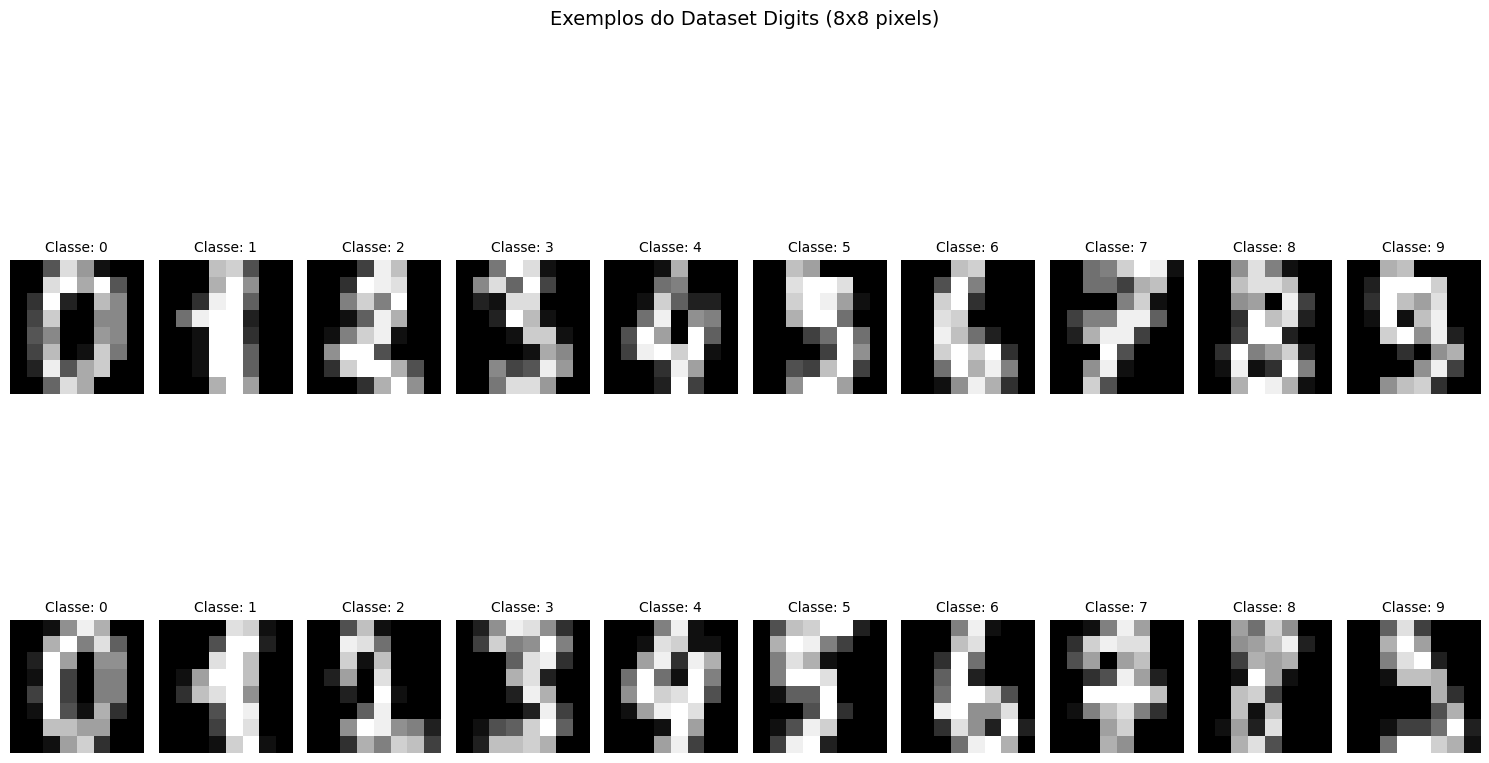


Valor mínimo dos pixels: 0.0
Valor máximo dos pixels: 1.0
Formato após flatten: (1797, 64)


In [9]:

print("Formato das imagens originais:", X.shape)
print("Dimensão de cada imagem:", X[0].shape)
print("Número de classes:", len(np.unique(y)))

# Visualizar algumas imagens do dataset
plt.figure(figsize=(15,10))

num_images = 20
for i in range(num_images):
    # Pega a imagem original (já está em formato 2D)
    image = X[i]  # Formato (8, 8)
    label = y[i]
    
    plt.subplot(2, 10, i+1)  # 2 linhas, 10 colunas para melhor visualização
    plt.title(f'Classe: {label}', fontsize=10)
    plt.axis('off')
    plt.imshow(image, cmap='gray')

plt.suptitle('Exemplos do Dataset Digits (8x8 pixels)', fontsize=14)
plt.tight_layout()
plt.show()

# Verificar valores dos pixels
print(f"\nValor mínimo dos pixels: {X.min()}")
print(f"Valor máximo dos pixels: {X.max()}")
print(f"Formato após flatten: {X_flat.shape}")

## 3. Métricas
Definição das métricas de avaliação.

In [10]:
def evaluate_model(y_true, y_pred):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Matriz de Confusão")
    plt.show()

## 4. MLP (Machine Learning)
Rede neural totalmente conectada baseada no notebook 02_asl.

## Recarregamento dos dados:

In [ ]:
# Exemplo: substitua pelo seu dataset
from sklearn.datasets import load_digits

data = load_digits()
X = data.images  # Shape: (1797, 8, 8)
y = data.target

# =========================================================================================================================
# NORMALIZAÇÃO: os pixels do dataset digits estão no intervalo [0, 16], então dividimos por 16 para normalizar para [0, 1].
# =========================================================================================================================
X = X / 16.0  # Agora os pixels estão no intervalo [0, 1]

# ==========================================================================================================================================
# FLATTEN PARA MLP: a MLP espera uma entrada 2D (n_samples, n_features), então precisamos achatar as imagens 8x8 em vetores de 64 elementos.
# ==========================================================================================================================================
X_flat = X.reshape((X.shape[0], -1))

# ====================================================================================================
# SPLIT: dividimos os dados em conjuntos de treinamento e teste. Para a MLP, usamos os dados achatados
# ====================================================================================================
X_train_f, X_test_f, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42
)

Epoch 1/10


c:\Users\pichau\.conda\envs\deep-learning\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5182 - loss: 1.9042 - val_accuracy: 0.8750 - val_loss: 1.3379
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8531 - loss: 0.9083 - val_accuracy: 0.8958 - val_loss: 0.5993
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9072 - loss: 0.4284 - val_accuracy: 0.9306 - val_loss: 0.3353
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9451 - loss: 0.2682 - val_accuracy: 0.9583 - val_loss: 0.2255
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9613 - loss: 0.1972 - val_accuracy: 0.9444 - val_loss: 0.2059
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9644 - loss: 0.1595 - val_accuracy: 0.9583 - val_loss: 0.1588
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9737 - loss: 0.1315 - val_accuracy: 0.9583 - val_loss: 0.1393
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9807 - loss: 0.1146 - val_accuracy: 0.9583 - val_loss: 0.1474
Epo

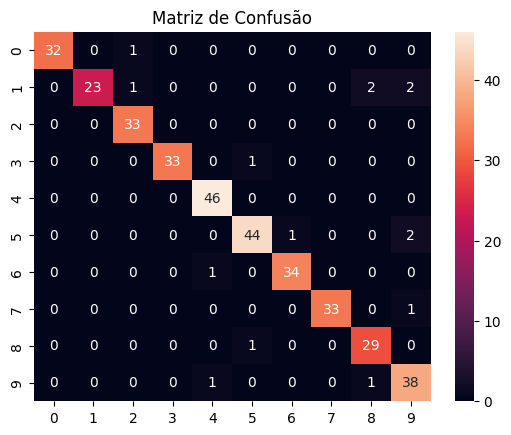

In [ ]:
# =================================================
# CONSTRUÇÃO DO MODELO MLP (Multi-Layer Perceptron)
# =================================================
# Modelo Sequential: empilha camadas linearmente, uma após a outra
mlp = models.Sequential([
    # Primeira camada oculta (Dense = camada totalmente conectada)
    # 128 neurônios, ativação ReLU (Rectified Linear Unit)
    # ReLU: f(x) = max(0, x) - ajuda a evitar vanishing gradient
    # input_shape: define o formato da entrada (número de features)
    layers.Dense(128, activation='relu', input_shape=(X_train_f.shape[1],)),
    
    # Segunda camada oculta
    # 64 neurônios, também com ativação ReLU
    # Quanto mais próximo da saída, menor o número de neurônios (extração de features mais abstratas)
    layers.Dense(64, activation='relu'),
    
    # Camada de saída
    # 10 neurônios = número de classes (dígitos 0-9)
    # Softmax: converte os outputs em probabilidades (soma = 1)
    # Cada neurônio representa a probabilidade da amostra pertencer àquela classe
    layers.Dense(10, activation='softmax')
])


# ====================
# COMPILAÇÃO DO MODELO
# ====================
# Configura o modelo para o treinamento
mlp.compile(
    # Adam: algoritmo de otimização adaptativo que combina vantagens do RMSprop e Momentum
    # É um dos otimizadores mais populares e funciona bem na maioria dos casos
    optimizer='adam',
    
    # sparse_categorical_crossentropy: função de perda para classificação multiclasse
    # Quando as labels são inteiros (0,1,2,...) e não one-hot encoded
    # Mede a diferença entre as probabilidades previstas e os labels reais
    loss='sparse_categorical_crossentropy',
    
    # Métricas a serem monitoradas durante o treinamento
    # 'accuracy' calcula a porcentagem de predições corretas
    metrics=['accuracy']
)


# =====================
# TREINAMENTO DO MODELO
# =====================
# fit: executa o treinamento do modelo
history_mlp = mlp.fit(
    X_train_f,          # Features de treino (normalizadas)
    y_train,            # Labels de treino (valores inteiros 0-9)
    epochs=10,          # Número de épocas (passadas completas no dataset)
    validation_split=0.1  # Separa 10% dos dados de treino para validação
    # A validação ajuda a monitorar overfitting (gap entre treino e validação)
)

# O objeto history contém as métricas de cada época:
# history.history['loss'] - perda no treino
# history.history['accuracy'] - acurácia no treino
# history.history['val_loss'] - perda na validação
# history.history['val_accuracy'] - acurácia na validação


# =====================
# PREDIÇÕES E AVALIAÇÃO
# =====================
# predict: gera as probabilidades de saída para cada classe
# Retorna uma matriz de shape (n_amostras, 10) com probabilidades
y_pred_probs = mlp.predict(X_test_f)

# np.argmax: encontra o índice do valor máximo ao longo do eixo 1 (colunas)
# Isso converte as probabilidades em classes preditas (0-9)
# Exemplo: [0.1, 0.05, 0.7, 0.15] -> classe 2
y_pred_mlp = np.argmax(y_pred_probs, axis=1)

# Avalia o modelo comparando as predições com os labels reais
# A função evaluate_model() (definida anteriormente) provavelmente:
# - Calcula acurácia
# - Gera classification report (precision, recall, f1-score)
# - Plota matriz de confusão
evaluate_model(y_test, y_pred_mlp)

## 5. CNN (Deep Learning)
Rede convolucional baseada no notebook 03_asl_cnn.

Dimensões originais das imagens: (1437, 8, 8)
Shape após adicionar canal: (1437, 8, 8, 1)


c:\Users\pichau\.conda\envs\deep-learning\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,914 (140.29 KB)

 Trainable params: 35,914 (140.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2575 - loss: 2.1716 - val_accuracy: 0.7014 - val_loss: 1.8660
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5568 - loss: 1.5464 - val_accuracy: 0.8472 - val_loss: 0.9450
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7077 - loss: 0.9304 - val_accuracy: 0.8750 - val_loss: 0.5578
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7896 - loss: 0.6830 - val_accuracy: 0.9236 - val_loss: 0.3392
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8461 - loss: 0.4890 - val_accuracy: 0.9583 - val_loss: 0.1993
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8716 - loss: 0.4179 - val_accuracy: 0.9722 - val_loss: 0.1659
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8894 - loss: 0.3575 - val_accuracy: 0.9653 - val_loss: 0.1244
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9142 - loss: 0.2953 - val_accuracy: 0.9792 - val_loss:

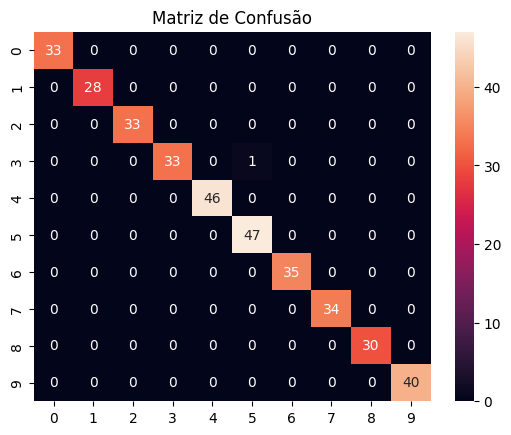

In [ ]:
data = load_digits()
X = data.images  # Shape: (1797, 8, 8)
y = data.target

# =========================================================================================================================
# NORMALIZAÇÃO: os pixels do dataset digits estão no intervalo [0, 16], então dividimos por 16 para normalizar para [0, 1].
# =========================================================================================================================
X = X / 16.0  # Agora os pixels estão no intervalo [0, 1]

# ====================================================================================================================
# SPLIT: dividimos os dados em conjuntos de treinamento e teste. Para a CNN, usamos os dados originais em formato 8x8.
# ====================================================================================================================

X_train_c, X_test_c, _, _ = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================================
# VERIFICAÇÃO DAS DIMENSÕES ORIGINAIS
# ============================================================================
# Antes de qualquer transformação, verificamos o formato original dos dados
# X_train_c originalmente tem shape (n_amostras, 8, 8) - imagens 8x8 pixels
print("Dimensões originais das imagens:", X_train_c.shape)

# ============================================================================
# ADIÇÃO DA DIMENSÃO DE CANAL
# ============================================================================
# As CNNs esperam dados no formato: (altura, largura, canais)
# [..., np.newaxis] adiciona uma nova dimensão no final do array
# Isso é equivalente a reshape(-1, 8, 8, 1)
# O "1" representa que as imagens são em escala de cinza (grayscale)
# Se fossem coloridas RGB, seria 3 canais
X_train_c = X_train_c[..., np.newaxis]  # Shape: (n, 8, 8, 1)
X_test_c = X_test_c[..., np.newaxis]

print("Shape após adicionar canal:", X_train_c.shape)

# ============================================================================
# CONSTRUÇÃO DO MODELO CNN (Convolutional Neural Network)
# ============================================================================
# Modelo Sequential: empilha as camadas na ordem em que os dados fluem
cnn = models.Sequential([
    
    # ========================================================================
    # PRIMEIRA CAMADA CONVOLUCIONAL
    # ========================================================================
    # Conv2D: aplica filtros convolucionais para extrair características espaciais
    # Parâmetros:
    #   - 32: número de filtros (feature detectors) que serão aprendidos
    #   - (3, 3): tamanho do kernel (janela deslizante 3x3 pixels)
    #   - activation='relu': função de ativação ReLU (max(0, x))
    #   - padding='same': adiciona bordas para manter dimensão de saída igual à entrada
    #     Isso evita que a imagem encolha após cada convolução
    #   - input_shape=(8, 8, 1): formato das imagens de entrada (altura, largura, canais)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(8, 8, 1)),
    
    # MaxPooling2D: reduz a dimensionalidade espacial (downsampling)
    # Parâmetros:
    #   - (2, 2): tamanho da janela de pooling (2x2)
    #   - Efeito: reduz cada bloco 2x2 para o valor máximo
    #   - Transformação: 8x8 -> 4x4 (redução de 50% em cada dimensão)
    # Benefícios: reduz parâmetros, aumenta robustez a pequenas translações
    layers.MaxPooling2D((2, 2)),  # Reduz de 8x8 para 4x4
    
    # ========================================================================
    # SEGUNDA CAMADA CONVOLUCIONAL
    # ========================================================================
    # 64 filtros: número dobrado em relação à camada anterior
    # Por que? Camadas mais profundas aprendem características mais complexas
    # e precisam de mais filtros para capturar todas as combinações possíveis
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    
    # Segundo pooling: reduz de 4x4 para 2x2
    # Após esta operação, a imagem tem apenas 2x2 pixels, mas com 64 canais (mapas de features)
    layers.MaxPooling2D((2, 2)),  # Reduz de 4x4 para 2x2
    
    # ========================================================================
    # CAMADA DE FLATTEN (ACHATAMENTO)
    # ========================================================================
    # Flatten: converte o volume 3D (2, 2, 64) em um vetor 1D (256)
    # Isso prepara os dados para as camadas densas (fully connected)
    # Sem o flatten, não podemos conectar camadas convolucionais com camadas densas
    layers.Flatten(),
    
    # ========================================================================
    # CAMADAS TOTALMENTE CONECTADAS (FULLY CONNECTED)
    # ========================================================================
    # Primeira camada densa: 64 neurônios com ativação ReLU
    # Esta camada combina as características extraídas pelas convoluções
    # para formar representações de alto nível
    layers.Dense(64, activation='relu'),
    
    # Dropout: técnica de regularização para prevenir overfitting
    # Parâmetro 0.5: desativa 50% dos neurônios aleatoriamente durante o treino
    # Por época, diferentes neurônios são desativados
    # Isso força a rede a ser mais robusta e não depender de neurônios específicos
    # Efeito similar ao "ensemble learning" - cria múltiplas sub-redes
    layers.Dropout(0.5),  # Adicionado para evitar overfitting
    
    # Camada de saída: 10 neurônios (classes 0-9)
    # Softmax: converte os outputs em probabilidades que somam 1
    # Cada neurônio representa a probabilidade da imagem pertencer àquela classe
    layers.Dense(10, activation='softmax')
])


# ============================================================================
# VISUALIZAÇÃO DA ARQUITETURA
# ============================================================================
# .summary() mostra:
# - Nome e tipo de cada camada
# - Output shape de cada camada (como os dados se transformam)
# - Número de parâmetros treináveis em cada camada
# - Total de parâmetros do modelo
# Isso é crucial para entender o fluxo de dados e detectar erros de dimensão
cnn.summary()

# ============================================================================
# COMPILAÇÃO DO MODELO
# ============================================================================
cnn.compile(
    # Adam: otimizador adaptativo que combina vantagens de outros métodos
    # Taxa de aprendizado ajustável automaticamente
    optimizer='adam',
    
    # sparse_categorical_crossentropy: função de perda para classificação multiclasse
    # Adequada quando as labels são inteiros (0-9) e não one-hot encoded
    # Mede a diferença entre a distribuição prevista e a real
    loss='sparse_categorical_crossentropy',
    
    # Métricas para monitorar durante treinamento
    # accuracy: porcentagem de predições corretas
    metrics=['accuracy']
)


# ============================================================================
# TREINAMENTO DO MODELO
# ============================================================================
history_cnn = cnn.fit(
    X_train_c,          # Features de treino (já com formato 8x8x1)
    y_train,            # Labels de treino (valores inteiros 0-9)
    epochs=20,          # Número de épocas (passadas completas no dataset)
    validation_split=0.1,  # Separa 10% dos dados de treino para validação
    verbose=1           # 1 = mostra barra de progresso
)

# O objeto history contém:
# history.history['loss'] - perda no treino a cada época
# history.history['accuracy'] - acurácia no treino a cada época
# history.history['val_loss'] - perda na validação a cada época
# history.history['val_accuracy'] - acurácia na validação a cada época


# ============================================================================
# PREDIÇÕES E AVALIAÇÃO
# ============================================================================
# predict: gera as probabilidades de saída para cada classe
# Retorna matriz (n_amostras, 10) com probabilidades
y_pred_probs = cnn.predict(X_test_c)

# np.argmax(axis=1): encontra o índice do maior valor em cada linha
# Converte probabilidades em classes preditas (0-9)
# Exemplo: [0.05, 0.1, 0.7, 0.15] -> classe 2
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

# Avalia o modelo com métricas completas
print("\n=== Resultados da CNN ===")
evaluate_model(y_test, y_pred_cnn)

## 6. Comparação Final
Análise comparativa entre MLP e CNN.

In [44]:
mlp_acc = accuracy_score(y_test, y_pred_mlp)
cnn_acc = accuracy_score(y_test, y_pred_cnn)

print(f"MLP Accuracy: {mlp_acc}")
print(f"CNN Accuracy: {cnn_acc}")

if cnn_acc > mlp_acc:
    print("CNN apresentou melhor desempenho.")
else:
    print("MLP apresentou melhor desempenho.")

MLP Accuracy: 0.9583333333333334
CNN Accuracy: 0.9972222222222222
CNN apresentou melhor desempenho.


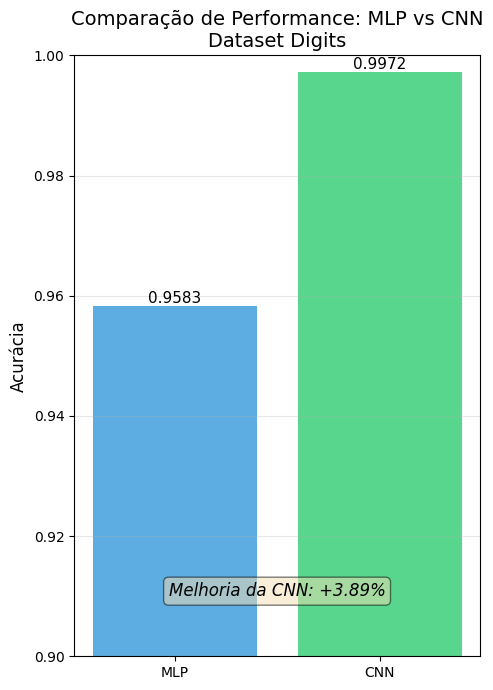

In [45]:
# Código para visualizar a diferença
import matplotlib.pyplot as plt


plt.figure(figsize=(5,7))
models = ['MLP', 'CNN']
accuracies = [mlp_acc, cnn_acc]
colors = ['#3498db', '#2ecc71']

bars = plt.bar(models, accuracies, color=colors, alpha=0.8)
plt.ylim(0.9, 1.0)  # Zoom na diferença
plt.ylabel('Acurácia', fontsize=12)
plt.title('Comparação de Performance: MLP vs CNN\nDataset Digits', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{acc:.4f}', 
             ha='center', va='bottom', fontsize=11)

# Calcular e mostrar melhoria
improvement = (cnn_acc - mlp_acc) * 100
plt.text(0.5, 0.91, f'Melhoria da CNN: +{improvement:.2f}%', 
         ha='center', fontsize=12, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### Resultados Obtidos

| Modelo | Acurácia | Desempenho |
|--------|----------|------------|
| **MLP** | 95.83% | Bom, mas com margem para melhoria |
| **CNN** | 99.72% | Excelente, quase perfeito |

### Análise dos Resultados

A Rede Neural Convolucional (CNN) apresentou **desempenho superior** em comparação com a Multilayer Perceptron (MLP), com uma diferença de **3.89 pontos percentuais** (99.72% vs 95.83%).

#### Por que a CNN teve melhor desempenho?

1. **Preservação da estrutura espacial**
   - A CNN mantém a organização 2D das imagens (8×8 pixels)
   - Consegue identificar padrões locais como bordas, cantos e formas características dos dígitos

2. **Redução de parâmetros**
   - A CNN utiliza convolução e pooling, reduzindo drasticamente o número de parâmetros
   - Isso ajuda a prevenir overfitting, especialmente em datasets menores como o Digits (1797 amostras)

3. **Extração hierárquica de features**
   - Primeiras camadas: detectam características simples (linhas, bordas)
   - Camadas mais profundas: combinam essas características para reconhecer padrões complexos (curvas, loops, estruturas específicas de cada dígito)

4. **Regularização eficaz**
   - A camada de Dropout (0.5) ajuda a prevenir overfitting
   - O MaxPooling proporciona invariância a pequenas translações

#### Interpretação dos 95.83% da MLP

A MLP ainda obteve um resultado muito bom, considerando que:
- É uma arquitetura mais simples
- Ignora completamente a estrutura espacial da imagem
- Trata cada pixel como uma característica independente

Os erros residuais da MLP provavelmente ocorrem em dígitos visualmente semelhantes (ex: 3 e 8, 1 e 7, 4 e 9), onde a falta de compreensão da estrutura espacial prejudica a discriminação.

### Conclusão

A CNN demonstrou ser **significativamente superior** para a tarefa de classificação de dígitos manuscritos, com uma acurácia quase perfeita (99.72%). Isso confirma a adequação das redes convolucionais para problemas de visão computacional, mesmo em imagens de baixa resolução como as do dataset Digits (8×8 pixels).

**Veredito:** ✅ **CNN vence** - A arquitetura convolucional é a escolha ideal para classificação de imagens.